<a href="https://colab.research.google.com/github/Kamruzzaman2200/Ai/blob/main/compitation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

#Load All Data Files

In [2]:
# Load all data files
try:
    train_df = pd.read_csv('/content/drive/MyDrive/DataSets/bubt-artificial-intelligence-conquest-2025/train.csv')
    test_df = pd.read_csv('/content/drive/MyDrive/DataSets/bubt-artificial-intelligence-conquest-2025/test.csv')
    sample_submission = pd.read_csv('/content/drive/MyDrive/DataSets/bubt-artificial-intelligence-conquest-2025/sample_submission.csv')
    print("All files loaded successfully!")
except:
    # Alternative paths for different environments
    try:
        train_df = pd.read_csv('/content/train.csv')
        test_df = pd.read_csv('/content/test.csv')
        sample_submission = pd.read_csv('/content/sample_submission.csv')
        print("All files loaded successfully from alternative path!")
    except:
        print("Please check file paths and ensure all files are available")
        raise

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)
print("\nSample submission columns:", sample_submission.columns.tolist())
print("\nSample submission head:")
print(sample_submission.head())

All files loaded successfully!
Training data shape: (15000, 20)
Test data shape: (10000, 19)
Sample submission shape: (10000, 4)

Sample submission columns: ['id', 'Status_C', 'Status_CL', 'Status_D']

Sample submission head:
      id  Status_C  Status_CL  Status_D
0  15000  0.628084   0.034788  0.337128
1  15001  0.628084   0.034788  0.337128
2  15002  0.628084   0.034788  0.337128
3  15003  0.628084   0.034788  0.337128
4  15004  0.628084   0.034788  0.337128


#Target Variable Analysis

=== TARGET VARIABLE DISTRIBUTION ===
Status
C     10234
D      4423
CL      343
Name: count, dtype: int64


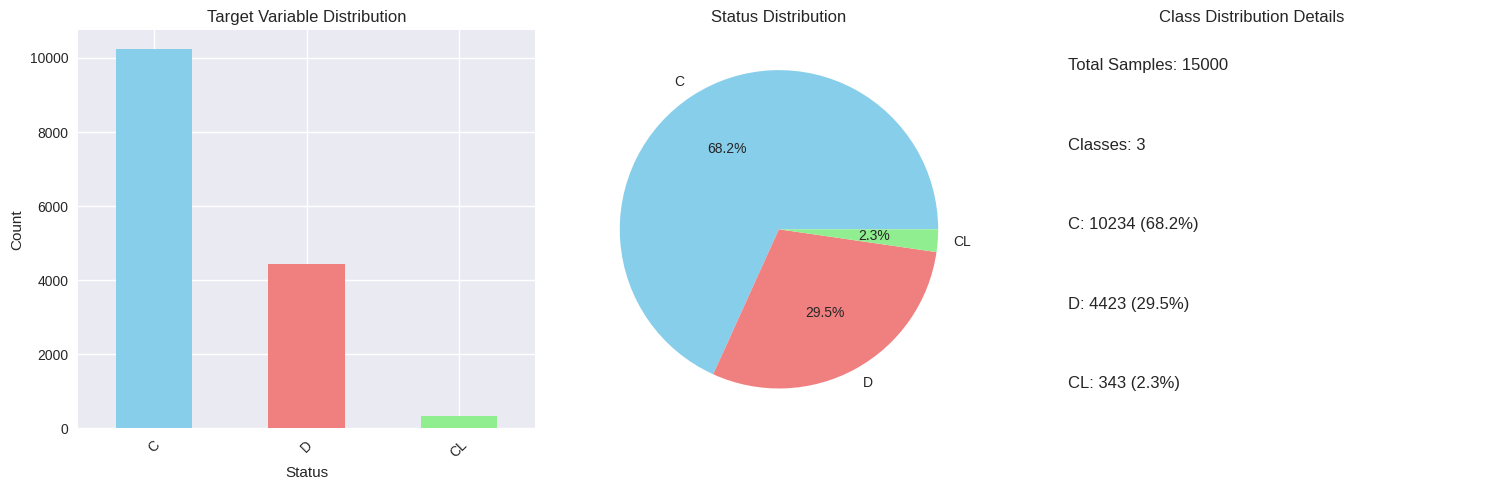


=== TARGET VARIABLE DETAILS ===
Most frequent class: C (10234)
Class balance ratio: 29.84
Dataset imbalance: Yes


In [3]:
# Analyze the target variable
print("=== TARGET VARIABLE DISTRIBUTION ===")
target_counts = train_df['Status'].value_counts()
print(target_counts)

plt.figure(figsize=(15, 5))

# Plot 1: Bar chart
plt.subplot(1, 3, 1)
target_counts.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Target Variable Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Plot 2: Pie chart
plt.subplot(1, 3, 2)
plt.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
        colors=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Status Distribution')

# Plot 3: Detailed statistics
plt.subplot(1, 3, 3)
plt.text(0.1, 0.9, f"Total Samples: {len(train_df)}", fontsize=12)
plt.text(0.1, 0.7, f"Classes: {len(target_counts)}", fontsize=12)
for i, (status, count) in enumerate(target_counts.items()):
    plt.text(0.1, 0.5 - i*0.2, f"{status}: {count} ({count/len(train_df)*100:.1f}%)", fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')
plt.title('Class Distribution Details')

plt.tight_layout()
plt.show()

# Additional target analysis
print("\n=== TARGET VARIABLE DETAILS ===")
print(f"Most frequent class: {target_counts.index[0]} ({target_counts.iloc[0]})")
print(f"Class balance ratio: {target_counts.max()/target_counts.min():.2f}")
print(f"Dataset imbalance: {'Yes' if target_counts.max()/target_counts.min() > 3 else 'No'}")

#Data Quality Check

=== TRAINING DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           8457 non-null   object 
 3   Age            15000 non-null  float64
 4   Sex            15000 non-null  object 
 5   Ascites        8464 non-null   object 
 6   Hepatomegaly   8453 non-null   object 
 7   Spiders        8449 non-null   object 
 8   Edema          15000 non-null  object 
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    6623 non-null   float64
 11  Albumin        15000 non-null  float64
 12  Copper         8338 non-null   float64
 13  Alk_Phos       8450 non-null   float64
 14  SGOT           8446 non-null   float64
 15  Tryglicerides  6574 non-null   float64
 16  Platelets      14462 non-null  float64
 17  Prothrombin    14981 no

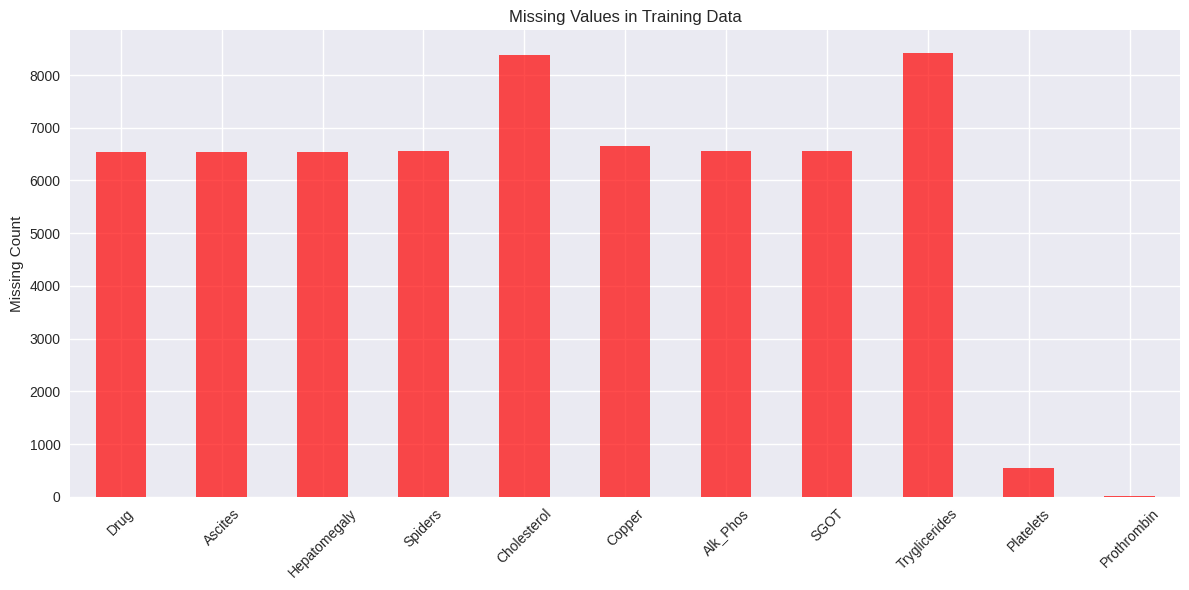

In [4]:
# Display basic info about training data
print("=== TRAINING DATA INFO ===")
print(train_df.info())
print("\n=== TEST DATA INFO ===")
print(test_df.info())

# Check missing values
print("\n=== MISSING VALUES ANALYSIS ===")
missing_train = train_df.isnull().sum()
missing_percent = (train_df.isnull().sum() / len(train_df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_train,
    'Missing Percentage': missing_percent
})
missing_cols = missing_info[missing_info['Missing Count'] > 0]
print(missing_cols)

# Visualize missing values
if not missing_cols.empty:
    plt.figure(figsize=(12, 6))
    missing_cols['Missing Count'].plot(kind='bar', color='red', alpha=0.7)
    plt.title('Missing Values in Training Data')
    plt.xticks(rotation=45)
    plt.ylabel('Missing Count')
    plt.tight_layout()
    plt.show()

#Data Preprocessing

In [6]:
# Create copies for preprocessing
train_clean = train_df.copy()
test_clean = test_df.copy()

print("=== DATA PREPROCESSING ===")

# Separate numerical and categorical columns
numerical_cols = train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train_clean.select_dtypes(include=['object']).columns.tolist()

# Remove target from categorical cols
if 'Status' in categorical_cols:
    categorical_cols.remove('Status')

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Identify columns with missing values
missing_cols_list = missing_cols.index.tolist()
num_missing = [col for col in missing_cols_list if col in numerical_cols]
cat_missing = [col for col in missing_cols_list if col in categorical_cols]

print(f"Numerical columns with missing: {num_missing}")
print(f"Categorical columns with missing: {cat_missing}")

# Handle missing values
print("\nHandling missing values...")

# Use KNN imputer for numerical columns
if num_missing:
    print("Using KNN imputer for numerical columns...")
    knn_imputer = KNNImputer(n_neighbors=5)
    train_clean[num_missing] = knn_imputer.fit_transform(train_clean[num_missing])
    test_clean[num_missing] = knn_imputer.transform(test_clean[num_missing])

# For categorical columns, use mode but add 'Missing' category
for col in cat_missing:
    print(f"Filling categorical column '{col}' with 'Missing'")
    train_clean[col].fillna('Missing', inplace=True)
    test_clean[col].fillna('Missing', inplace=True)

# Verify no missing values remain
print(f"\nRemaining missing values in train: {train_clean.isnull().sum().sum()}")
print(f"Remaining missing values in test: {test_clean.isnull().sum().sum()}")

print("Preprocessing completed!")

=== DATA PREPROCESSING ===
Numerical columns: 13
Categorical columns: 6
Numerical columns with missing: ['Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
Categorical columns with missing: ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders']

Handling missing values...
Using KNN imputer for numerical columns...
Filling categorical column 'Drug' with 'Missing'
Filling categorical column 'Ascites' with 'Missing'
Filling categorical column 'Hepatomegaly' with 'Missing'
Filling categorical column 'Spiders' with 'Missing'

Remaining missing values in train: 0
Remaining missing values in test: 0
Preprocessing completed!


#Feature Engineering

In [8]:
def create_advanced_features(df):
    df_copy = df.copy()

    # Clinical ratios and scores
    if all(col in df_copy.columns for col in ['Bilirubin', 'Albumin']):
        df_copy['Bilirubin_Albumin_Ratio'] = df_copy['Bilirubin'] / (df_copy['Albumin'] + 1e-6)

    if all(col in df_copy.columns for col in ['Platelets', 'Prothrombin']):
        df_copy['Platelets_Prothrombin_Index'] = df_copy['Platelets'] / (df_copy['Prothrombin'] + 1e-6)

    if all(col in df_copy.columns for col in ['Alk_Phos', 'SGOT']):
        df_copy['Liver_Enzyme_Ratio'] = df_copy['Alk_Phos'] / (df_copy['SGOT'] + 1e-6)

    # Age in years (assuming Age is in days)
    if 'Age' in df_copy.columns:
        df_copy['Age_Years'] = df_copy['Age'] / 365.25

    # Create binary flags for missing values in important clinical features
    important_clinical = ['Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets']
    for col in important_clinical:
        if col in df_copy.columns:
            df_copy[f'{col}_missing'] = df_copy[col].isnull().astype(int)

    return df_copy

print("Creating advanced features...")
train_clean = create_advanced_features(train_clean)
test_clean = create_advanced_features(test_clean)

print(f"Training shape after feature engineering: {train_clean.shape}")
print(f"Test shape after feature engineering: {test_clean.shape}")

Creating advanced features...
Training shape after feature engineering: (15000, 32)
Test shape after feature engineering: (10000, 31)


#Encoding Categorical Variables

In [10]:
print("=== ENCODING CATEGORICAL VARIABLES ===")

# Encode categorical variables
categorical_cols_to_encode = [col for col in categorical_cols if col != 'Status']

label_encoders = {}
for col in categorical_cols_to_encode:
    if col in train_clean.columns:
        le = LabelEncoder()
        # Combine train and test for consistent encoding
        combined = pd.concat([train_clean[col], test_clean[col]], axis=0)
        le.fit(combined.astype(str))

        train_clean[col] = le.transform(train_clean[col].astype(str))
        test_clean[col] = le.transform(test_clean[col].astype(str))
        label_encoders[col] = le

        print(f"Encoded {col}: {len(le.classes_)} categories")

# Encode target variable
target_encoder = LabelEncoder()
train_clean['Status_encoded'] = target_encoder.fit_transform(train_clean['Status'])

print(f"\nTarget encoding: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")
print("Encoding completed!")

=== ENCODING CATEGORICAL VARIABLES ===
Encoded Drug: 3 categories
Encoded Sex: 2 categories
Encoded Ascites: 3 categories
Encoded Hepatomegaly: 3 categories
Encoded Spiders: 4 categories
Encoded Edema: 3 categories

Target encoding: {'C': np.int64(0), 'CL': np.int64(1), 'D': np.int64(2)}
Encoding completed!


#Correlation Analysis

=== CORRELATION ANALYSIS ===


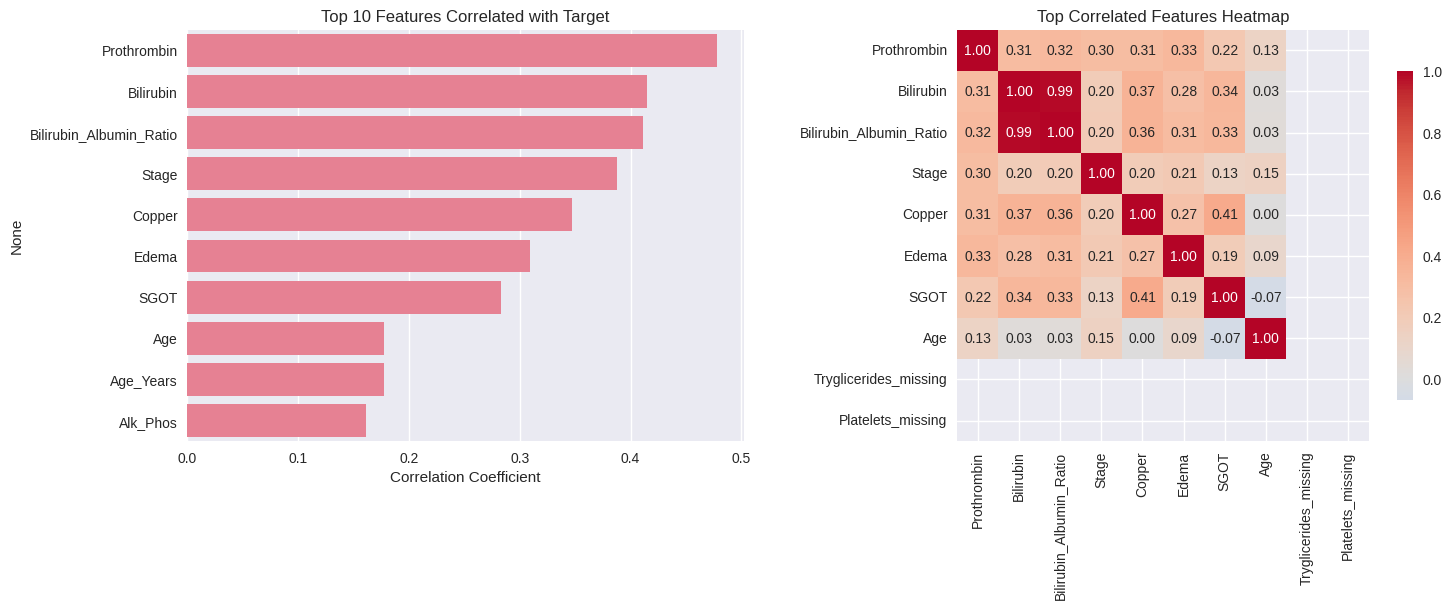


Top 10 Positive Correlations with Target:
  Prothrombin: 0.4781
  Bilirubin: 0.4150
  Bilirubin_Albumin_Ratio: 0.4114
  Stage: 0.3876
  Copper: 0.3475
  Edema: 0.3094
  SGOT: 0.2831
  Age: 0.1779
  Age_Years: 0.1779
  Alk_Phos: 0.1610


In [11]:
print("=== CORRELATION ANALYSIS ===")

# Calculate correlation matrix
correlation_matrix = train_clean.select_dtypes(include=[np.number]).corr()

# Plot correlation with target
plt.figure(figsize=(15, 6))

# Plot 1: Top correlations with target
plt.subplot(1, 2, 1)
if 'Status_encoded' in correlation_matrix.columns:
    target_corr = correlation_matrix['Status_encoded'].sort_values(ascending=False)
    target_corr = target_corr[target_corr.index != 'Status_encoded']

    # Take top 10 features
    top_features = target_corr.head(10)
    sns.barplot(x=top_features.values, y=top_features.index)
    plt.title('Top 10 Features Correlated with Target')
    plt.xlabel('Correlation Coefficient')
else:
    plt.text(0.5, 0.5, 'Target not found in correlation matrix',
             ha='center', va='center', transform=plt.gca().transAxes)

# Plot 2: Correlation heatmap for top correlated features
plt.subplot(1, 2, 2)
if 'Status_encoded' in correlation_matrix.columns:
    # Select top 15 correlated features
    top_corr_features = target_corr.head(8).index.tolist() + target_corr.tail(2).index.tolist()
    if 'Status_encoded' in top_corr_features:
        top_corr_features.remove('Status_encoded')

    if len(top_corr_features) > 1:
        top_corr_matrix = correlation_matrix.loc[top_corr_features, top_corr_features]
        sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', center=0,
                   square=True, cbar_kws={"shrink": .8}, fmt='.2f')
        plt.title('Top Correlated Features Heatmap')
    else:
        plt.text(0.5, 0.5, 'Not enough correlated features',
                 ha='center', va='center', transform=plt.gca().transAxes)
else:
    plt.text(0.5, 0.5, 'Target not available',
             ha='center', va='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

# Print correlation details
if 'Status_encoded' in correlation_matrix.columns:
    print("\nTop 10 Positive Correlations with Target:")
    for feature, corr in target_corr.head(10).items():
        print(f"  {feature}: {corr:.4f}")

#Prepare Features for Modeling

In [12]:
print("=== PREPARING FEATURES FOR MODELING ===")

# Define features to use (excluding ID and target-related columns)
exclude_cols = ['id', 'Status', 'Status_encoded']
feature_cols = [col for col in train_clean.columns if col not in exclude_cols]

print(f"Using {len(feature_cols)} features for modeling")

# Prepare X and y
X = train_clean[feature_cols]
y = train_clean['Status_encoded']

# Split the data with stratification
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Class distribution in training: {np.bincount(y_train)}")
print(f"Class distribution in validation: {np.bincount(y_val)}")

# Scale the data for algorithms that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Feature preparation completed!")

=== PREPARING FEATURES FOR MODELING ===
Using 30 features for modeling
Training set: (12000, 30)
Validation set: (3000, 30)
Class distribution in training: [8187  274 3539]
Class distribution in validation: [2047   69  884]
Feature preparation completed!


#Initialize Multiple Classifiers

In [13]:
print("=== INITIALIZING MULTIPLE CLASSIFIERS ===")

# Define multiple classifiers with optimized parameters
classifiers = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000, class_weight='balanced', C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight='balanced',
        max_depth=10, min_samples_split=5
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, random_state=42, learning_rate=0.1, max_depth=6
    ),
    'SVM': SVC(
        probability=True, random_state=42, class_weight='balanced',
        C=1.0, kernel='rbf'
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42, class_weight='balanced', max_depth=10
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, random_state=42, learning_rate=0.1
    ),
    'Extra Trees': ExtraTreesClassifier(
        n_estimators=100, random_state=42, class_weight='balanced'
    ),
    'Naive Bayes': GaussianNB()
}

print(f"Initialized {len(classifiers)} classifiers")
for name in classifiers:
    print(f"  - {name}")

=== INITIALIZING MULTIPLE CLASSIFIERS ===
Initialized 9 classifiers
  - Logistic Regression
  - Random Forest
  - Gradient Boosting
  - SVM
  - K-Nearest Neighbors
  - Decision Tree
  - AdaBoost
  - Extra Trees
  - Naive Bayes


#Train and Evaluate Models

In [14]:
print("=== TRAINING AND EVALUATING MODELS ===")
print("=" * 50)

results = {}
predictions = {}

for name, clf in classifiers.items():
    print(f"\n🔧 Training {name}...")

    try:
        # Use scaled data for certain algorithms
        if name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors', 'Naive Bayes']:
            X_tr = X_train_scaled
            X_v = X_val_scaled
        else:
            X_tr = X_train
            X_v = X_val

        # Train model
        clf.fit(X_tr, y_train)

        # Make predictions
        y_pred = clf.predict(X_v)
        y_pred_proba = clf.predict_proba(X_v)

        # Calculate metrics
        accuracy = accuracy_score(y_val, y_pred)
        cv_scores = cross_val_score(clf, X_tr, y_train, cv=5, scoring='accuracy', n_jobs=-1)

        # Store results
        results[name] = {
            'model': clf,
            'accuracy': accuracy,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
        predictions[name] = y_pred_proba

        print(f" {name}:")
        print(f"   Validation Accuracy: {accuracy:.4f}")
        print(f"   CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

    except Exception as e:
        print(f" Error training {name}: {str(e)}")
        results[name] = None

print("\n All models trained successfully!")

=== TRAINING AND EVALUATING MODELS ===

🔧 Training Logistic Regression...
 Logistic Regression:
   Validation Accuracy: 0.7113
   CV Accuracy: 0.7027 (+/- 0.0173)

🔧 Training Random Forest...
 Random Forest:
   Validation Accuracy: 0.8343
   CV Accuracy: 0.8406 (+/- 0.0086)

🔧 Training Gradient Boosting...
 Gradient Boosting:
   Validation Accuracy: 0.8533
   CV Accuracy: 0.8553 (+/- 0.0082)

🔧 Training SVM...
 SVM:
   Validation Accuracy: 0.7737
   CV Accuracy: 0.7742 (+/- 0.0040)

🔧 Training K-Nearest Neighbors...
 K-Nearest Neighbors:
   Validation Accuracy: 0.8227
   CV Accuracy: 0.8210 (+/- 0.0101)

🔧 Training Decision Tree...
 Decision Tree:
   Validation Accuracy: 0.7573
   CV Accuracy: 0.7604 (+/- 0.0066)

🔧 Training AdaBoost...
 AdaBoost:
   Validation Accuracy: 0.8480
   CV Accuracy: 0.8495 (+/- 0.0076)

🔧 Training Extra Trees...
 Extra Trees:
   Validation Accuracy: 0.8463
   CV Accuracy: 0.8465 (+/- 0.0094)

🔧 Training Naive Bayes...
 Naive Bayes:
   Validation Accuracy: 0.

#Model Performance Comparison

=== MODEL PERFORMANCE COMPARISON ===
              Model  Validation Accuracy  CV Mean Accuracy   CV Std
  Gradient Boosting             0.853333          0.855250 0.004105
           AdaBoost             0.848000          0.849500 0.003822
        Extra Trees             0.846333          0.846500 0.004711
      Random Forest             0.834333          0.840583 0.004303
K-Nearest Neighbors             0.822667          0.821000 0.005059
        Naive Bayes             0.776333          0.776417 0.007084
                SVM             0.773667          0.774250 0.002014
      Decision Tree             0.757333          0.760417 0.003302
Logistic Regression             0.711333          0.702667 0.008631


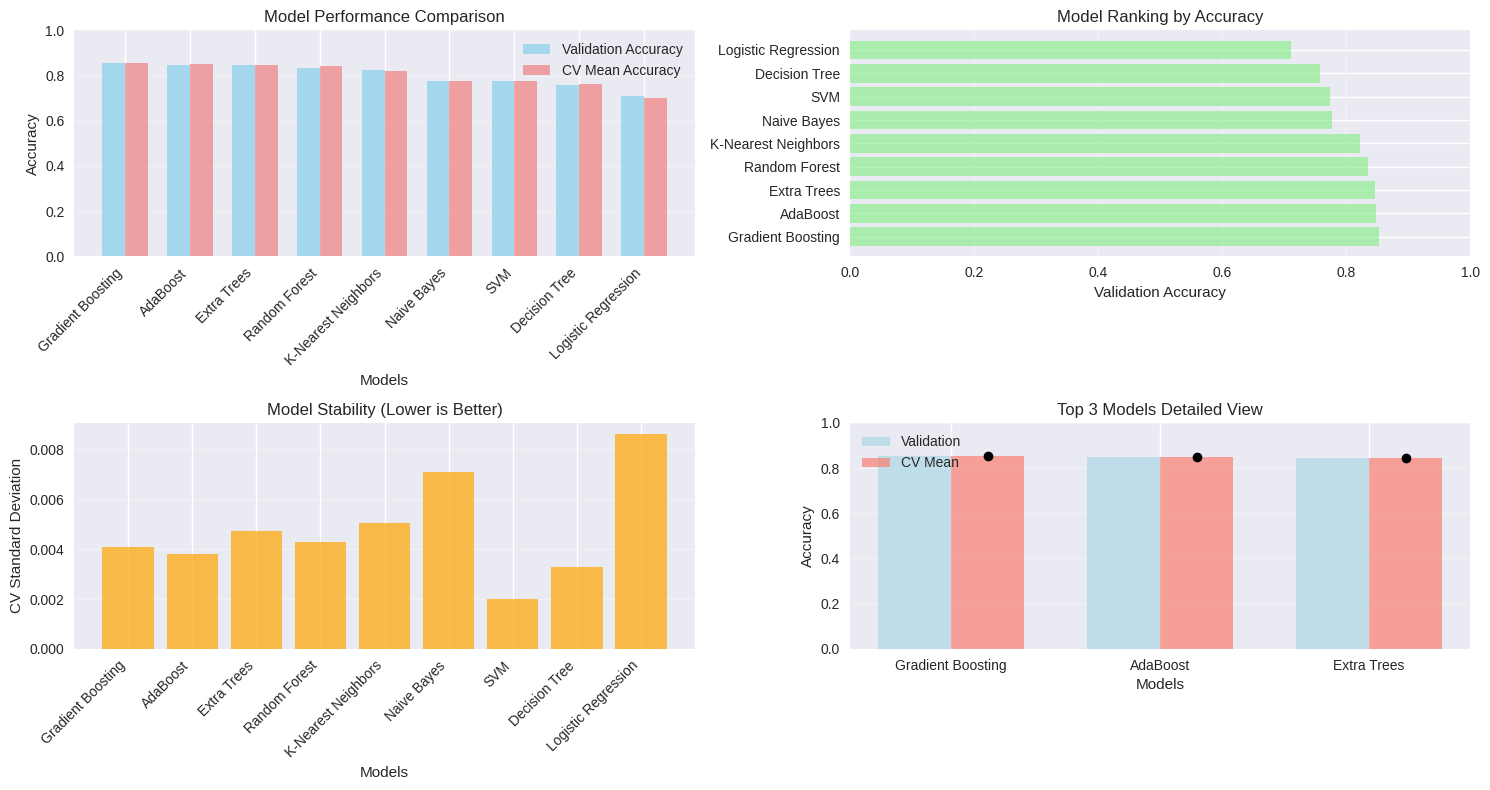


 BEST MODEL: Gradient Boosting
   Validation Accuracy: 0.8533
   CV Accuracy: 0.8553


In [16]:
print("=== MODEL PERFORMANCE COMPARISON ===")

# Create results dataframe
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Validation Accuracy': [results[name]['accuracy'] if results[name] else 0 for name in results],
    'CV Mean Accuracy': [results[name]['cv_mean'] if results[name] else 0 for name in results],
    'CV Std': [results[name]['cv_std'] if results[name] else 0 for name in results]
}).sort_values('Validation Accuracy', ascending=False)

print(results_df.to_string(index=False))

# Plot model comparison
plt.figure(figsize=(15, 8))

# Plot 1: Accuracy comparison
plt.subplot(2, 2, 1)
x_pos = np.arange(len(results_df))
width = 0.35

plt.bar(x_pos - width/2, results_df['Validation Accuracy'], width,
        label='Validation Accuracy', alpha=0.7, color='skyblue')
plt.bar(x_pos + width/2, results_df['CV Mean Accuracy'], width,
        label='CV Mean Accuracy', alpha=0.7, color='lightcoral')

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xticks(x_pos, results_df['Model'], rotation=45, ha='right')
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Plot 2: Performance ranking
plt.subplot(2, 2, 2)
plt.barh(results_df['Model'], results_df['Validation Accuracy'], color='lightgreen', alpha=0.7)
plt.xlabel('Validation Accuracy')
plt.title('Model Ranking by Accuracy')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)

# Plot 3: Model stability
plt.subplot(2, 2, 3)
plt.bar(results_df['Model'], results_df['CV Std'], color='orange', alpha=0.7)
plt.xlabel('Models')
plt.ylabel('CV Standard Deviation')
plt.title('Model Stability (Lower is Better)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Plot 4: Top 3 models detailed view
plt.subplot(2, 2, 4)
top_3 = results_df.head(3)
x_pos_top = np.arange(len(top_3))
plt.bar(x_pos_top - width/2, top_3['Validation Accuracy'], width,
        label='Validation', alpha=0.7, color='lightblue')
plt.bar(x_pos_top + width/2, top_3['CV Mean Accuracy'], width,
        label='CV Mean', alpha=0.7, color='salmon')
plt.errorbar(x_pos_top + width/2, top_3['CV Mean Accuracy'],
             yerr=top_3['CV Std'], fmt='o', color='black', capsize=5)

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Top 3 Models Detailed View')
plt.xticks(x_pos_top, top_3['Model'])
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print best model
best_model_info = results_df.iloc[0]
print(f"\n BEST MODEL: {best_model_info['Model']}")
print(f"   Validation Accuracy: {best_model_info['Validation Accuracy']:.4f}")
print(f"   CV Accuracy: {best_model_info['CV Mean Accuracy']:.4f}")

#Learning Curves

=== LEARNING CURVES ANALYSIS ===


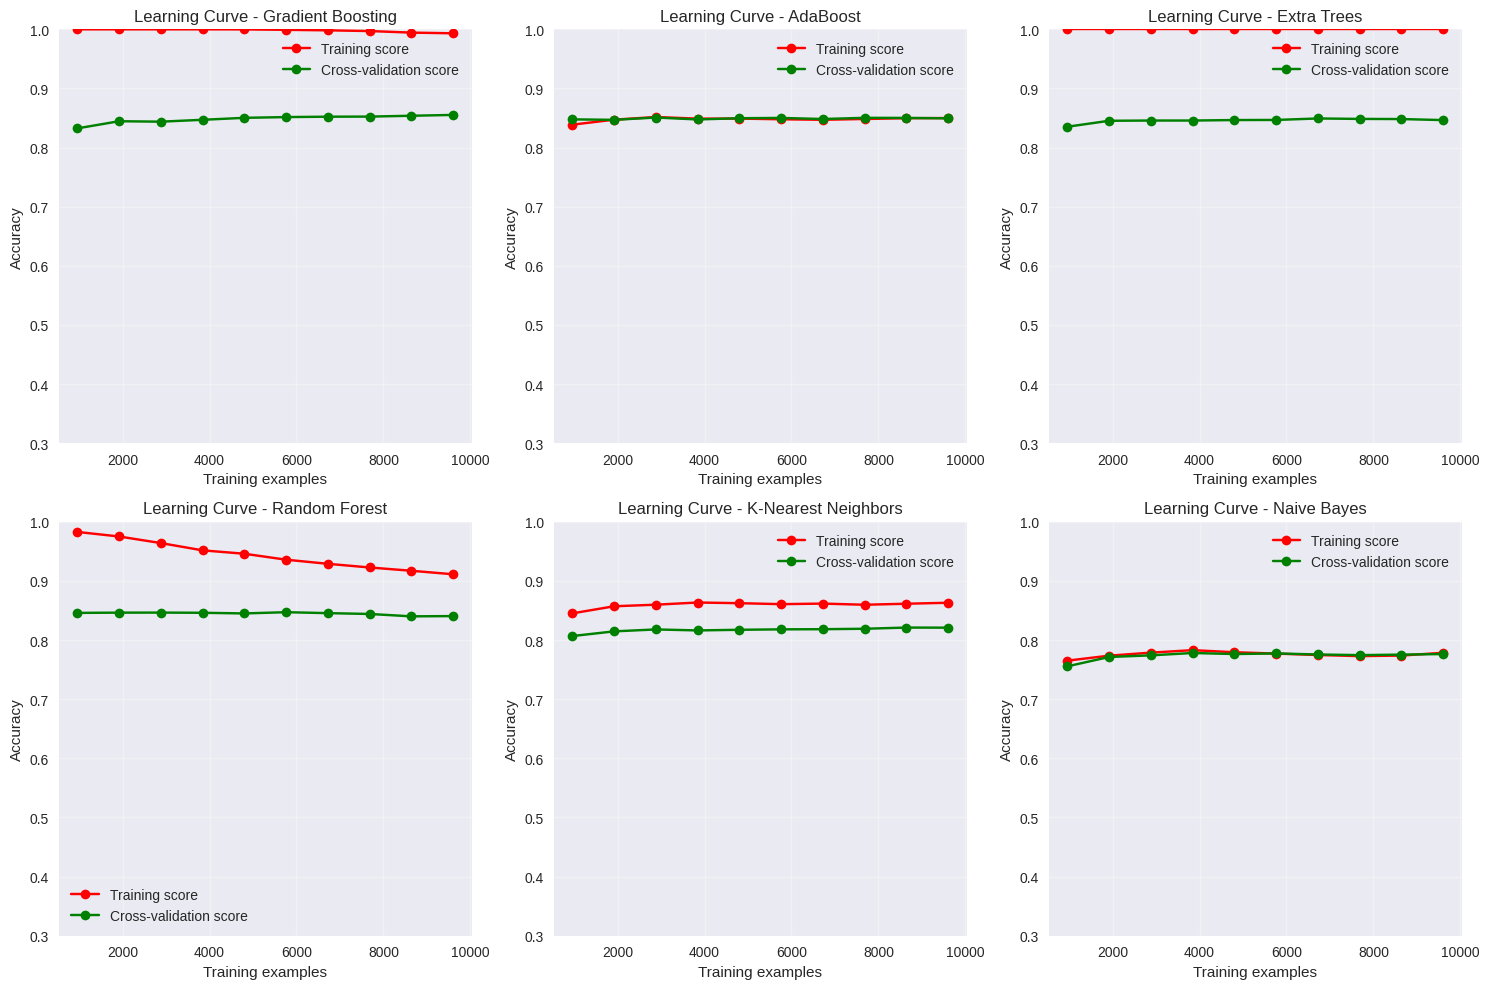

In [17]:
print("=== LEARNING CURVES ANALYSIS ===")

def plot_learning_curves_for_top_models(top_models_dict, X, y, title):
    """Plot learning curves for top performing models"""
    plt.figure(figsize=(15, 10))

    for i, (name, model_info) in enumerate(top_models_dict.items()):
        model = model_info['model']

        # Use scaled data if needed
        if name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors', 'Naive Bayes']:
            X_plot = scaler.transform(X)
        else:
            X_plot = X

        train_sizes, train_scores, test_scores = learning_curve(
            model, X_plot, y, cv=5, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='accuracy', random_state=42
        )

        train_scores_mean = np.mean(train_scores, axis=1)
        test_scores_mean = np.mean(test_scores, axis=1)

        plt.subplot(2, 3, i+1)
        plt.plot(train_sizes, train_scores_mean, 'o-', color='red', label='Training score')
        plt.plot(train_sizes, test_scores_mean, 'o-', color='green', label='Cross-validation score')
        plt.xlabel('Training examples')
        plt.ylabel('Accuracy')
        plt.title(f'Learning Curve - {name}')
        plt.legend(loc='best')
        plt.grid(alpha=0.3)
        plt.ylim(0.3, 1.0)

    plt.tight_layout()
    plt.show()

# Plot for top 6 models
top_6_models = {name: results[name] for name in results_df.head(6)['Model'] if results[name] is not None}
plot_learning_curves_for_top_models(top_6_models, X_train, y_train, "Top Models Learning Curves")

#ROC Curves

=== ROC CURVES ANALYSIS ===


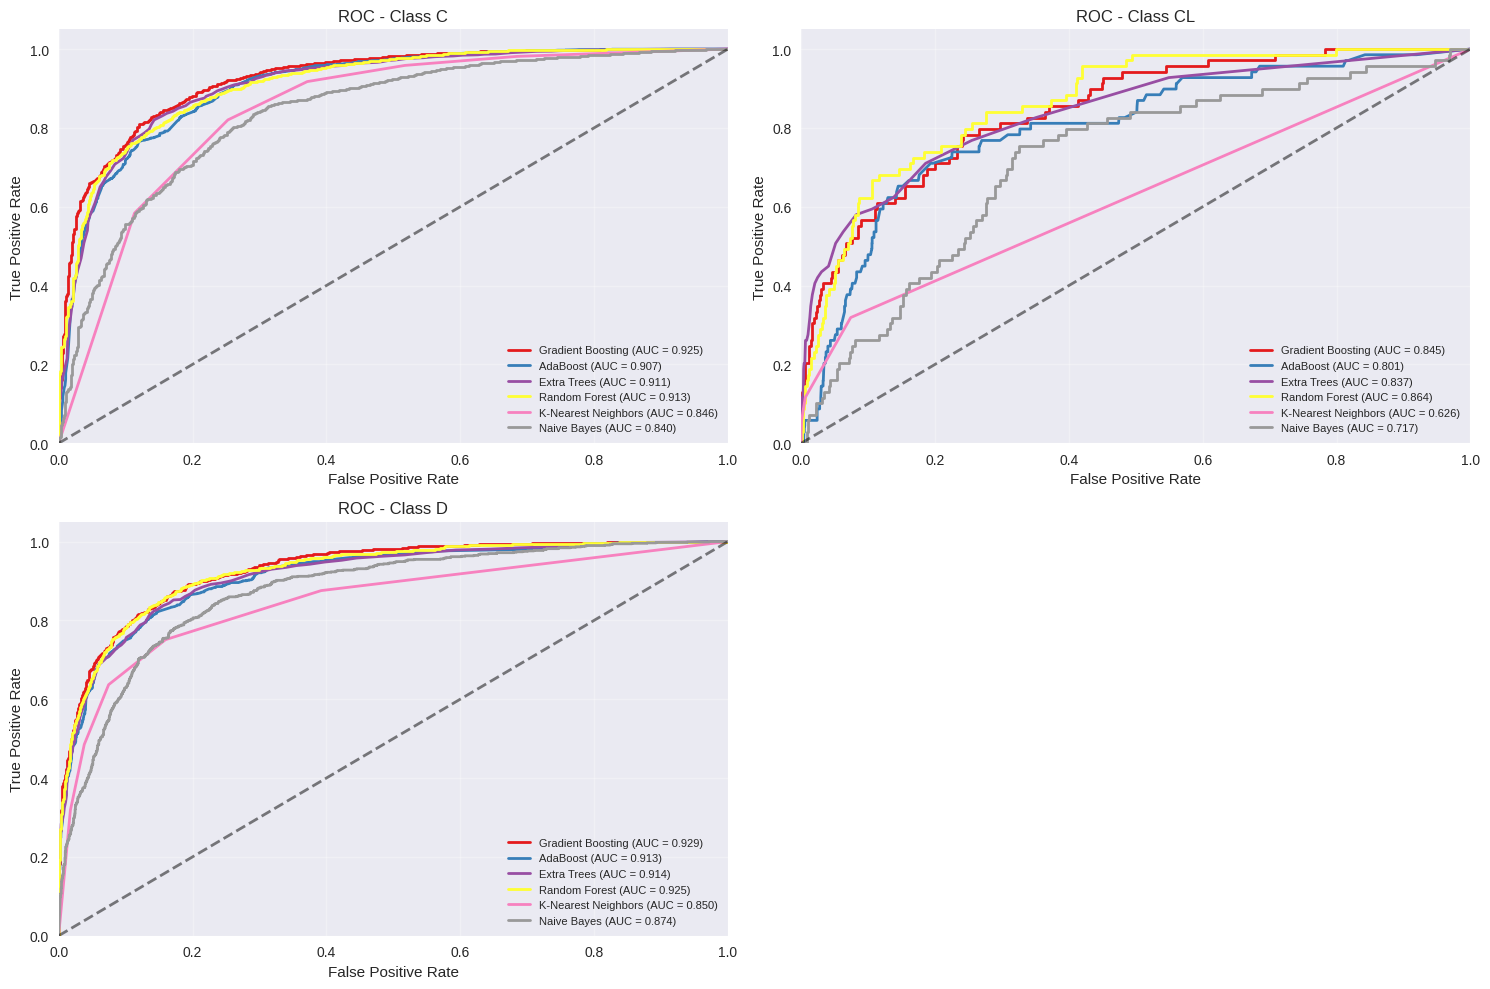


Macro AUC Scores:
  Gradient Boosting: 0.8998
  AdaBoost: 0.8737
  Extra Trees: 0.8875
  Random Forest: 0.9010
  K-Nearest Neighbors: 0.7737
  Naive Bayes: 0.8105


In [18]:
print("=== ROC CURVES ANALYSIS ===")

def plot_roc_curves(models_dict, predictions_dict, y_true, class_names):
    """Plot ROC curves for multiple models"""
    plt.figure(figsize=(15, 10))

    n_classes = len(class_names)
    colors = plt.cm.Set1(np.linspace(0, 1, len(models_dict)))

    # Plot for each class
    for class_idx in range(n_classes):
        plt.subplot(2, 2, class_idx + 1)

        for i, (name, model_info) in enumerate(models_dict.items()):
            if predictions_dict.get(name) is not None:
                y_pred_proba = predictions_dict[name]
                fpr, tpr, _ = roc_curve(y_true == class_idx, y_pred_proba[:, class_idx])
                roc_auc = auc(fpr, tpr)

                plt.plot(fpr, tpr, color=colors[i], lw=2,
                        label=f'{name} (AUC = {roc_auc:.3f})')

        plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC - Class {class_names[class_idx]}')
        plt.legend(fontsize=8)
        plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot ROC curves for top models
plot_roc_curves(top_6_models, predictions, y_val, target_encoder.classes_)

# Calculate macro AUC scores
print("\nMacro AUC Scores:")
macro_auc_scores = {}
for name in top_6_models:
    if predictions.get(name) is not None:
        y_pred_proba = predictions[name]
        # Calculate macro AUC
        auc_scores = []
        for class_idx in range(len(target_encoder.classes_)):
            fpr, tpr, _ = roc_curve(y_val == class_idx, y_pred_proba[:, class_idx])
            auc_scores.append(auc(fpr, tpr))
        macro_auc = np.mean(auc_scores)
        macro_auc_scores[name] = macro_auc
        print(f"  {name}: {macro_auc:.4f}")

#Hyperparameter Tuning for Best Model

In [19]:
print("=== HYPERPARAMETER TUNING ===")

# Select the best model for tuning
best_model_name = results_df.iloc[0]['Model']
print(f"Tuning best model: {best_model_name}")

# Define parameter grids for different models
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['auto', 'sqrt']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 4, 5, 6],
        'min_samples_split': [2, 5, 10]
    },
    'Logistic Regression': {
        'C': [0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }
}

if best_model_name in param_grids:
    print(f"Performing randomized search for {best_model_name}...")

    model = classifiers[best_model_name]
    param_grid = param_grids[best_model_name]

    # Use appropriate data
    if best_model_name in ['Logistic Regression', 'SVM']:
        X_tune = X_train_scaled
    else:
        X_tune = X_train

    # Randomized search
    random_search = RandomizedSearchCV(
        model, param_grid, n_iter=20, cv=5,
        scoring='accuracy', n_jobs=-1, random_state=42, verbose=1
    )

    random_search.fit(X_tune, y_train)

    print(f"Best parameters: {random_search.best_params_}")
    print(f"Best CV score: {random_search.best_score_:.4f}")

    # Update the best model
    best_model = random_search.best_estimator_
else:
    print(f"No parameter grid defined for {best_model_name}, using default model")
    best_model = results[best_model_name]['model']

print("Hyperparameter tuning completed!")

=== HYPERPARAMETER TUNING ===
Tuning best model: Gradient Boosting
Performing randomized search for Gradient Boosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 3, 'learning_rate': 0.1}
Best CV score: 0.8592
Hyperparameter tuning completed!


#Final Model Evaluation

=== FINAL MODEL EVALUATION ===
Final Model: Gradient Boosting
Validation Accuracy: 0.8517

Classification Report:
              precision    recall  f1-score   support

           C       0.87      0.93      0.90      2047
          CL       0.36      0.07      0.12        69
           D       0.81      0.72      0.76       884

    accuracy                           0.85      3000
   macro avg       0.68      0.58      0.60      3000
weighted avg       0.84      0.85      0.84      3000



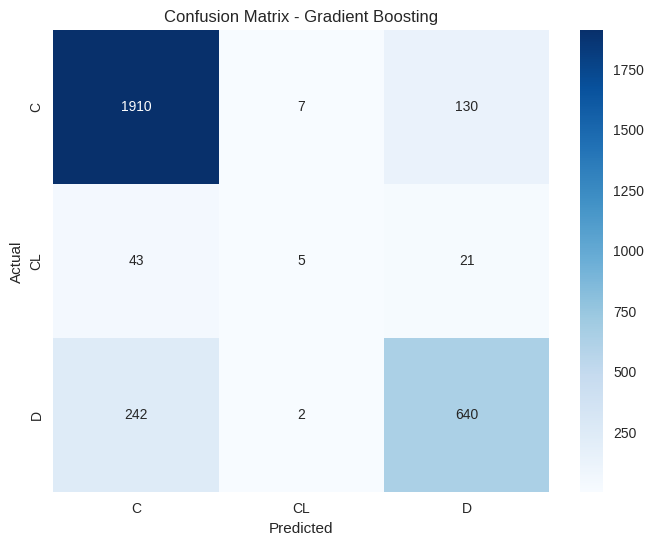

In [20]:
print("=== FINAL MODEL EVALUATION ===")

# Evaluate best model on validation set
if best_model_name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors', 'Naive Bayes']:
    X_eval = X_val_scaled
else:
    X_eval = X_val

# Make predictions
y_pred_final = best_model.predict(X_eval)
y_pred_proba_final = best_model.predict_proba(X_eval)

# Calculate final metrics
final_accuracy = accuracy_score(y_val, y_pred_final)

print(f"Final Model: {best_model_name}")
print(f"Validation Accuracy: {final_accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_final, target_names=target_encoder.classes_))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#Test Predictions

In [21]:
print("=== MAKING TEST PREDICTIONS ===")

# Prepare test data
X_test = test_clean[feature_cols]

# Scale if necessary
if best_model_name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors', 'Naive Bayes']:
    X_test_scaled = scaler.transform(X_test)
    test_predictions = best_model.predict_proba(X_test_scaled)
else:
    test_predictions = best_model.predict_proba(X_test)

print(f"Test predictions shape: {test_predictions.shape}")

# Create submission dataframe
submission = pd.DataFrame({
    'id': test_clean['id'],
    'Status_C': test_predictions[:, 0],
    'Status_CL': test_predictions[:, 1],
    'Status_D': test_predictions[:, 2]
})

print("Submission sample:")
print(submission.head())

# Verify submission format matches sample
print(f"\nSubmission shape: {submission.shape}")
print(f"Sample submission shape: {sample_submission.shape}")
print(f"Columns match: {set(submission.columns) == set(sample_submission.columns)}")

=== MAKING TEST PREDICTIONS ===
Test predictions shape: (10000, 3)
Submission sample:
      id  Status_C  Status_CL  Status_D
0  15000  0.917602   0.008572  0.073827
1  15001  0.976841   0.002396  0.020763
2  15002  0.800441   0.031944  0.167614
3  15003  0.030608   0.004022  0.965370
4  15004  0.958070   0.002881  0.039049

Submission shape: (10000, 4)
Sample submission shape: (10000, 4)
Columns match: True


#Submission and Final Summary

In [ ]:
print("=== SAVING SUBMISSION ===")

# Save submission file
submission.to_csv('submission.csv', index=False)
print(" Submission file saved as 'submission.csv'")

# Final verification
print("\n=== FINAL VERIFICATION ===")
print(f"Model Used: {best_model_name}")
print(f"Validation Accuracy: {final_accuracy:.4f}")
print(f"Submission File: submission.csv")
print(f"Test Samples: {len(submission)}")

# Check probability ranges
print(f"\n Probability Ranges:")
for col in ['Status_C', 'Status_CL', 'Status_D']:
    print(f"   {col}: [{submission[col].min():.6f}, {submission[col].max():.6f}]")

# Verify probability sums
submission['sum'] = submission[['Status_C', 'Status_CL', 'Status_D']].sum(axis=1)
print(f"\n Probability Sum Validation:")
print(f"   Min sum: {submission['sum'].min():.8f}")
print(f"   Max sum: {submission['sum'].max():.8f}")
print(f"   All sums close to 1.0: {np.allclose(submission['sum'], 1.0, atol=1e-6)}")

# Final summary
print(f"\n ANALYSIS COMPLETE!")
print(f" Best Model: {best_model_name}")
print(f" Expected Performance: {final_accuracy:.4f} accuracy")
print(f" Ready for submission!")